# Compute eigenfaces on cat dataset

In [1]:
from skimage import io
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import glob
from sklearn.decomposition import PCA
from skimage.transform import SimilarityTransform
from skimage.transform import warp
import os
import pathlib
from preprocess import preprocess_all_cats, preprocess_one_cat, create_u_byte_image_from_vector

In [3]:
cat_dir = os.getcwd()+'/training_data/'
model_cat_str ="00000001_012.jpg"
model_cat = os.path.join(cat_dir,model_cat_str)
model_cat_landmarks = os.path.join(cat_dir, model_cat_str, '.cat')

preprocess_all_cats(cat_dir, 'preprocessed_cats')

/home/ludvikpet/Documents/DTU/02503-grind/lud/exercises/ex8-CatsCatsCats/training_data/


/home/ludvikpet/.venv/02503/lib/python3.13/site-packages/skimage/_shared/utils.py:328: UserWarning: preprocessed_cats/00000059_002_preprocessed.jpg is a low contrast image
  return func(*args, **kwargs)


In [3]:
preprocessed_cats = glob.glob(os.getcwd()+'/preprocessed_cats/*.jpg')
n_samples = len(preprocessed_cats)
model_cat = io.imread(preprocessed_cats[0])
h,w,c = model_cat.shape[0], model_cat.shape[1], model_cat.shape[2]
n_features = h*w*c

# Load data matrix
if os.path.exists('data/data_matrix.npy'):
    data_matrix = np.load('data/data_matrix.npy')
else:
    data_matrix = np.zeros((n_samples, n_features))

    for i, cat_path in enumerate(preprocessed_cats):
        preprocessed_cat = io.imread(cat_path)
        data_matrix[i, :] = preprocessed_cat.flatten()
    np.save('data/data_matrix.npy', data_matrix)

data_matrix = data_matrix[:100]
data_matrix.shape

(100, 388800)

In [26]:
data_matrix.shape

(100, 388800)

In [25]:
avg_cat_1D = data_matrix.mean(axis=0)
avg_cat = create_u_byte_image_from_vector(avg_cat_1D, h, w, c)
io.imshow(avg_cat)
io.show()

TypeError: 'float' object cannot be interpreted as an integer

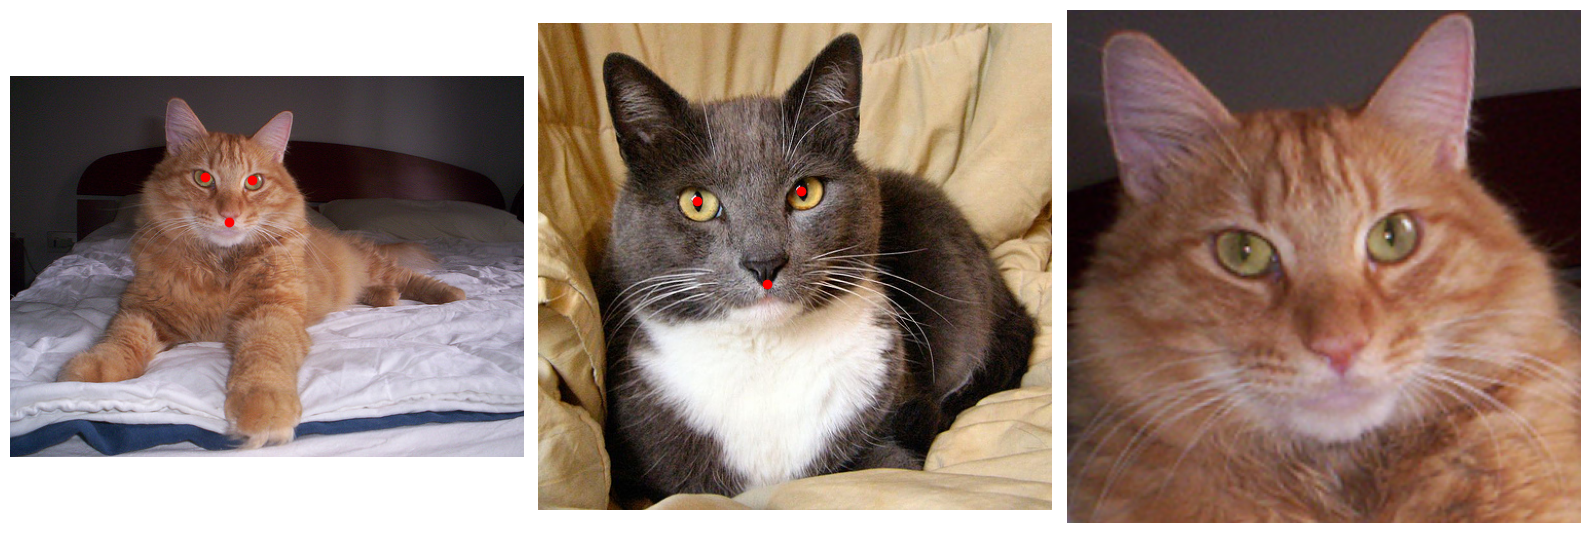

In [19]:
preprocess_one_cat()

Closest cat to the missing cat: 19


/tmp/ipykernel_5379/3325821123.py:13: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(closest_cat_img)
/tmp/ipykernel_5379/3325821123.py:14: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


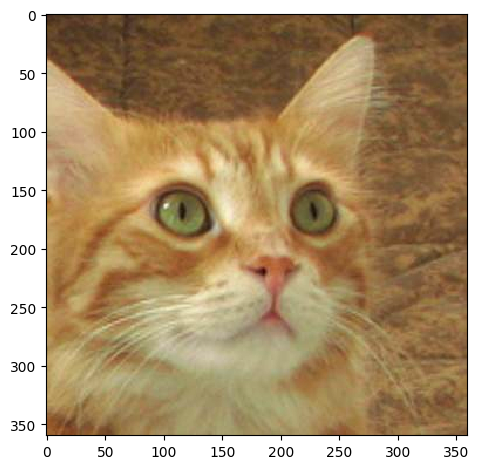

In [6]:
missing_cat_pp = io.imread('data/MissingCatProcessed.jpg')
flat_cat = missing_cat_pp.flatten()

# Compute SSD from reference missing cat image to dataset
sub_data = data_matrix - flat_cat
sub_distances = np.linalg.norm(sub_data, axis = 1)

closest_cat_idx = np.argmin(sub_distances)
print(f"Closest cat to the missing cat: {closest_cat_idx}")
# sub_distances.shape

closest_cat_img = create_u_byte_image_from_vector(data_matrix[closest_cat_idx], h,w,c)
io.imshow(closest_cat_img)
io.show()

Closest cat to the missing cat: 21


/tmp/ipykernel_5379/2113257796.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(furthest_cat_idx)
/tmp/ipykernel_5379/2113257796.py:7: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


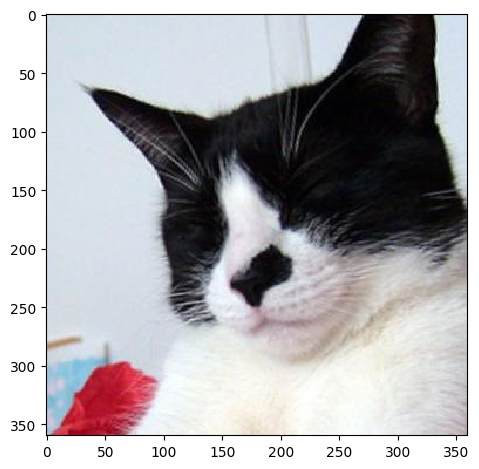

In [7]:
furthest_cat_idx = np.argmax(sub_distances)
print(f"Closest cat to the missing cat: {furthest_cat_idx}")
# sub_distances.shape

furthest_cat_idx = create_u_byte_image_from_vector(data_matrix[furthest_cat_idx], h,w,c)
io.imshow(furthest_cat_idx)
io.show()

### PCA on the cats

In [10]:
# Compute PCA on data_matrix
n_components = 10
cats_pca = PCA(n_components=n_components)
cats_pca.fit(data_matrix)

# Explained variance
cats_pca.explained_variance_, cats_pca.explained_variance_ratio_

(array([3.16554127e+08, 2.14663293e+08, 1.79746785e+08, 1.14173369e+08,
        6.16794656e+07, 5.44939840e+07, 4.53933437e+07, 4.49080840e+07,
        3.82657174e+07, 3.41380921e+07]),
 array([0.19132247, 0.12974056, 0.10863734, 0.06900536, 0.03727851,
        0.03293567, 0.02743533, 0.02714204, 0.02312746, 0.02063276]))

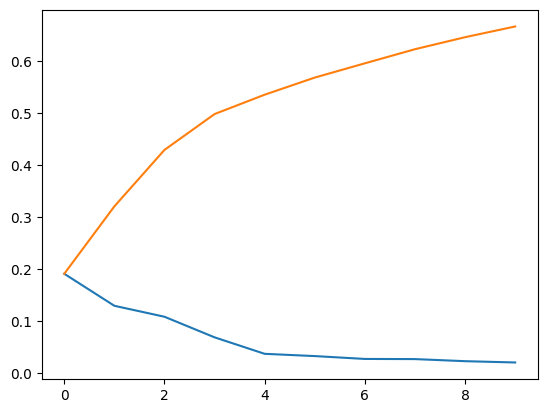

In [13]:
plt.plot(np.arange(n_components), cats_pca.explained_variance_ratio_)
plt.plot(np.arange(n_components), np.cumsum(cats_pca.explained_variance_ratio_))
plt.show()

~19% of the variance is explained by the first PC. After 10, ~70% of the variance is explained.

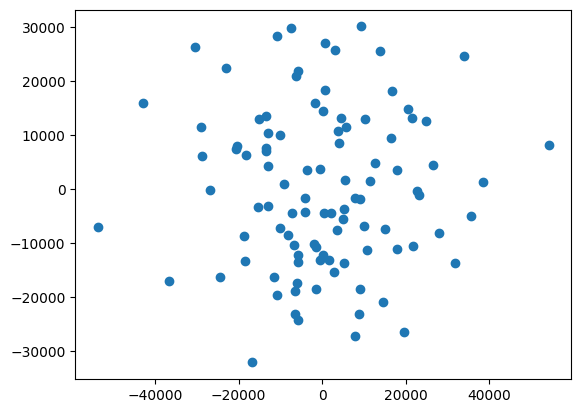

In [16]:
# Project cats onto PCA space:
components = cats_pca.transform(data_matrix)

# Plotting the cats over the first two PCs:
plt.scatter(components[:,0], components[:,1])
plt.show()

### Cats in space

In [17]:
components[:,0].shape

(100,)

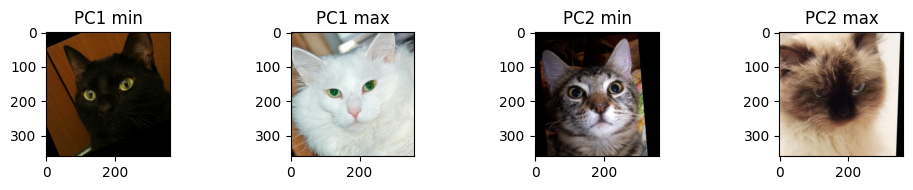

In [22]:
# Find most extreme cats
pca1_min_idx = np.argmin(components[:,0])
pca1_max_idx = np.argmax(components[:,0])
pca2_min_idx = np.argmin(components[:,1])
pca2_max_idx = np.argmax(components[:,1])

fig, ax = plt.subplots(ncols=4, figsize=(10,2))
ax[0].imshow(create_u_byte_image_from_vector(data_matrix[pca1_min_idx],h,w,c))
ax[0].set_title('PC1 min')
ax[1].imshow(create_u_byte_image_from_vector(data_matrix[pca1_max_idx],h,w,c))
ax[1].set_title('PC1 max')
ax[2].imshow(create_u_byte_image_from_vector(data_matrix[pca2_min_idx],h,w,c))
ax[2].set_title('PC2 min')
ax[3].imshow(create_u_byte_image_from_vector(data_matrix[pca2_max_idx],h,w,c))
ax[3].set_title('PC2 max')
fig.tight_layout()
plt.show()

In [23]:
w = 1.3
synth_cat = avg_cat + w * cats_pca.components_[0,:]

NameError: name 'avg_cat' is not defined